# Data Exploration: Brent Oil Prices and Geopolitical Events

## Objectives
1. Load and examine Brent oil price data
2. Explore the compiled geopolitical events dataset
3. Initial visualization and summary statistics
4. Data quality assessment and cleaning

## Context
This notebook serves as the foundation for our change point analysis, establishing the data quality and basic properties before proceeding to more sophisticated time series analysis.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

## 1. Load Brent Oil Price Data

In [2]:
# Since we can't access the Google Sheet directly, we'll create a function to download Brent oil data
# from an alternative source (EIA or FRED)
import yfinance as yf

def download_brent_data(start_date='1987-05-20', end_date='2022-09-30'):
    """
    Download Brent crude oil data using yfinance
    Note: This is a fallback method since direct Google Sheet access failed
    """
    try:
        # Download Brent crude futures data (BZ=F)
        brent = yf.download('BZ=F', start=start_date, end=end_date)
        
        # Reset index to get Date as column
        brent = brent.reset_index()
        
        # Select relevant columns and rename
        brent_data = brent[['Date', 'Close']].copy()
        brent_data.columns = ['Date', 'Price']
        
        # Convert Date to datetime
        brent_data['Date'] = pd.to_datetime(brent_data['Date'])
        
        print(f"Downloaded {len(brent_data)} observations from {brent_data['Date'].min()} to {brent_data['Date'].max()}")
        return brent_data
        
    except Exception as e:
        print(f"Error downloading data: {e}")
        return None

# Load the data
brent_data = download_brent_data()

if brent_data is not None:
    display(brent_data.head())
    display(brent_data.tail())
    print(f"\nDataset shape: {brent_data.shape}")
else:
    print("Failed to download Brent oil data. Please check internet connection or try alternative source.")

[*********************100%***********************]  1 of 1 completed

Downloaded 3766 observations from 2007-07-30 00:00:00 to 2022-09-29 00:00:00


,Date,Price
0,2007-07-30,75.739998
1,2007-07-31,77.050003
2,2007-08-01,75.349998
3,2007-08-02,75.760002
4,2007-08-03,74.750000


,Date,Price
3761,2022-09-23,86.150002
3762,2022-09-26,84.059998
3763,2022-09-27,86.269997
3764,2022-09-28,89.320000
3765,2022-09-29,88.489998



Dataset shape: (3766, 2)


## 2. Load Geopolitical Events Data

In [3]:
# Load the geopolitical events data
try:
    events_data = pd.read_csv('../data/geopolitical_events.csv')
    
    # Convert Date to datetime
    events_data['Date'] = pd.to_datetime(events_data['Date'])
    
    print("Geopolitical Events Data:")
    display(events_data.head(10))
    
    print(f"\nTotal events compiled: {len(events_data)}")
    print(f"Date range: {events_data['Date'].min()} to {events_data['Date'].max()}")
    
    # Event type distribution
    print("\nEvent Type Distribution:")
    display(events_data['Type'].value_counts())
    
    # Impact level distribution
    print("\nExpected Impact Distribution:")
    display(events_data['Expected_Impact'].value_counts())
    
except Exception as e:
    print(f"Error loading events data: {e}")

Geopolitical Events Data:


,Date,Event,Type,Description,Expected_Impact
0,1990-08-02,Iraq invades Kuwait,Military Conflict,Iraq's invasion of Kuwait triggered the Gulf W...,High
1,1991-01-17,Gulf War begins,Military Conflict,"Operation Desert Storm began, creating uncerta...",High
2,1997-07-01,Asian Financial Crisis,Economic Crisis,Severe currency crisis affected global oil demand,Medium
3,1998-12-01,OPEC Production Increase,OPEC Policy,"OPEC increased production quotas, leading to p...",Medium
4,2001-09-11,9/11 Terrorist Attacks,Geopolitical Event,Attacks created economic uncertainty and affec...,High
5,2003-03-20,Iraq War begins,Military Conflict,US-led invasion of Iraq disrupted regional oil...,High
6,2005-08-29,Hurricane Katrina,Natural Disaster,Hurricane damaged Gulf of Mexico oil infrastru...,High
7,2008-07-03,Oil Price Peak,Market Event,Brent oil reached record high of $147/barrel,High
8,2008-09-15,Global Financial Crisis,Economic Crisis,Lehman Brothers collapse triggered global rece...,High
9,2010-04-20,Deepwater Horizon Disaster,Environmental Disaster,BP oil spill disrupted Gulf of Mexico production,Medium



Total events compiled: 27
Date range: 1990-08-02 00:00:00 to 2022-12-05 00:00:00

Event Type Distribution:


Type
Military Conflict         6
OPEC Policy               6
Economic Crisis           2
Market Event              2
Political Sanctions       2
Geopolitical Event        1
Natural Disaster          1
Environmental Disaster    1
Political Unrest          1
Political Agreement       1
Political Decision        1
Military Attack           1
Health Crisis             1
Political Policy          1
Name: count, dtype: int64


Expected Impact Distribution:


Expected_Impact
High      18
Medium     9
Name: count, dtype: int64

## 3. Data Quality Assessment

In [4]:
def assess_data_quality(df, data_name="Dataset"):
    """
    Comprehensive data quality assessment
    """
    print(f"=== {data_name} Quality Assessment ===")
    
    # Basic info
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print("\nMissing Values:")
        print(missing[missing > 0])
    else:
        print("\n✓ No missing values detected")
    
    # Data types
    print("\nData Types:")
    print(df.dtypes)
    
    # Duplicates
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"\n⚠ {duplicates} duplicate rows found")
    else:
        print("\n✓ No duplicate rows detected")
    
    # Numeric column statistics (if any)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print("\nNumeric Columns Summary:")
        display(df[numeric_cols].describe())
    
    print("\n" + "="*50 + "\n")

# Assess quality of both datasets
if brent_data is not None:
    assess_data_quality(brent_data, "Brent Oil Price Data")

if 'events_data' in locals():
    assess_data_quality(events_data, "Geopolitical Events Data")

=== Brent Oil Price Data Quality Assessment ===
Shape: (3766, 2)
Columns: ['Date', 'Price']

✓ No missing values detected

Data Types:
Date     datetime64[ns]
Price           float64
dtype: object

✓ No duplicate rows detected

Numeric Columns Summary:


,Price
count,3766.000000
mean,78.138534
std,25.952673
min,19.330000
25%,56.419998
50%,74.250000
75%,104.607500
max,146.080002




=== Geopolitical Events Data Quality Assessment ===
Shape: (27, 5)
Columns: ['Date', 'Event', 'Type', 'Description', 'Expected_Impact']

✓ No missing values detected

Data Types:
Date               datetime64[ns]
Event                      object
Type                       object
Description                object
Expected_Impact            object
dtype: object

✓ No duplicate rows detected




## 4. Initial Visualizations

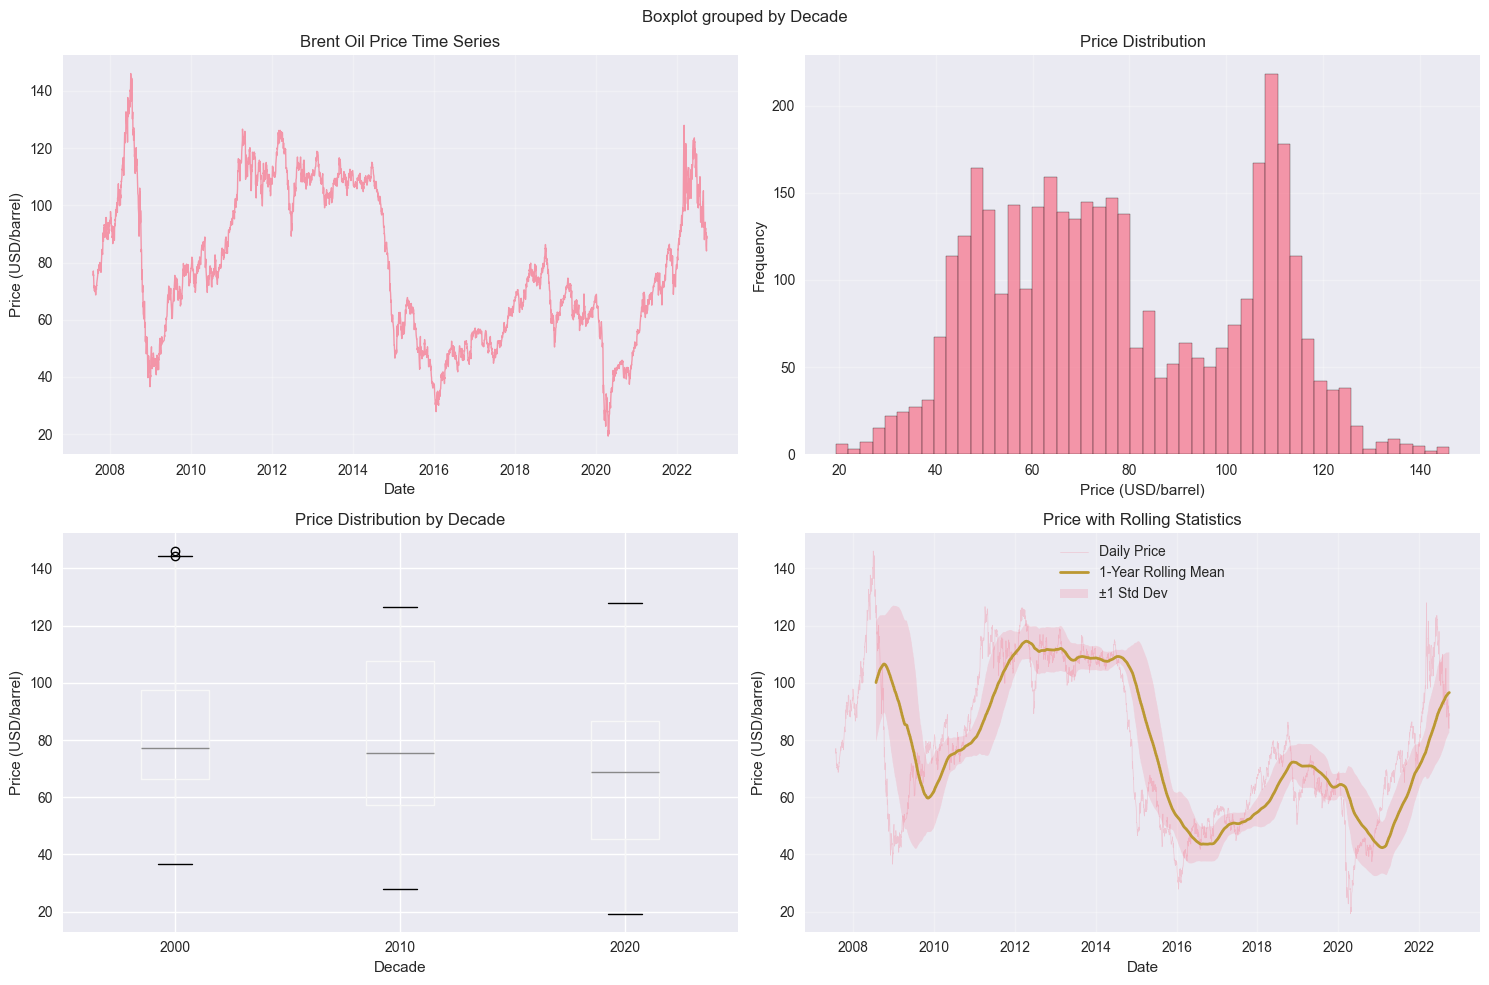

Brent Oil Price Summary Statistics:


count    3766.000000
mean       78.138534
std        25.952673
min        19.330000
25%        56.419998
50%        74.250000
75%       104.607500
max       146.080002
Name: Price, dtype: float64

In [5]:
if brent_data is not None:
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Brent Oil Price Data Exploration', fontsize=16, fontweight='bold')
    
    # 1. Time series plot
    axes[0, 0].plot(brent_data['Date'], brent_data['Price'], linewidth=1, alpha=0.7)
    axes[0, 0].set_title('Brent Oil Price Time Series')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Price (USD/barrel)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Price distribution
    axes[0, 1].hist(brent_data['Price'], bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Price Distribution')
    axes[0, 1].set_xlabel('Price (USD/barrel)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Box plot by decade
    brent_data['Decade'] = (brent_data['Date'].dt.year // 10) * 10
    brent_data.boxplot(column='Price', by='Decade', ax=axes[1, 0])
    axes[1, 0].set_title('Price Distribution by Decade')
    axes[1, 0].set_xlabel('Decade')
    axes[1, 0].set_ylabel('Price (USD/barrel)')
    
    # 4. Rolling statistics
    brent_data['Rolling_Mean'] = brent_data['Price'].rolling(window=252).mean()  # ~1 year
    brent_data['Rolling_Std'] = brent_data['Price'].rolling(window=252).std()
    
    axes[1, 1].plot(brent_data['Date'], brent_data['Price'], alpha=0.3, label='Daily Price', linewidth=0.5)
    axes[1, 1].plot(brent_data['Date'], brent_data['Rolling_Mean'], label='1-Year Rolling Mean', linewidth=2)
    axes[1, 1].fill_between(brent_data['Date'], 
                          brent_data['Rolling_Mean'] - brent_data['Rolling_Std'],
                          brent_data['Rolling_Mean'] + brent_data['Rolling_Std'],
                          alpha=0.2, label='±1 Std Dev')
    axes[1, 1].set_title('Price with Rolling Statistics')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Price (USD/barrel)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("Brent Oil Price Summary Statistics:")
    display(brent_data['Price'].describe())

## 5. Events Timeline Visualization

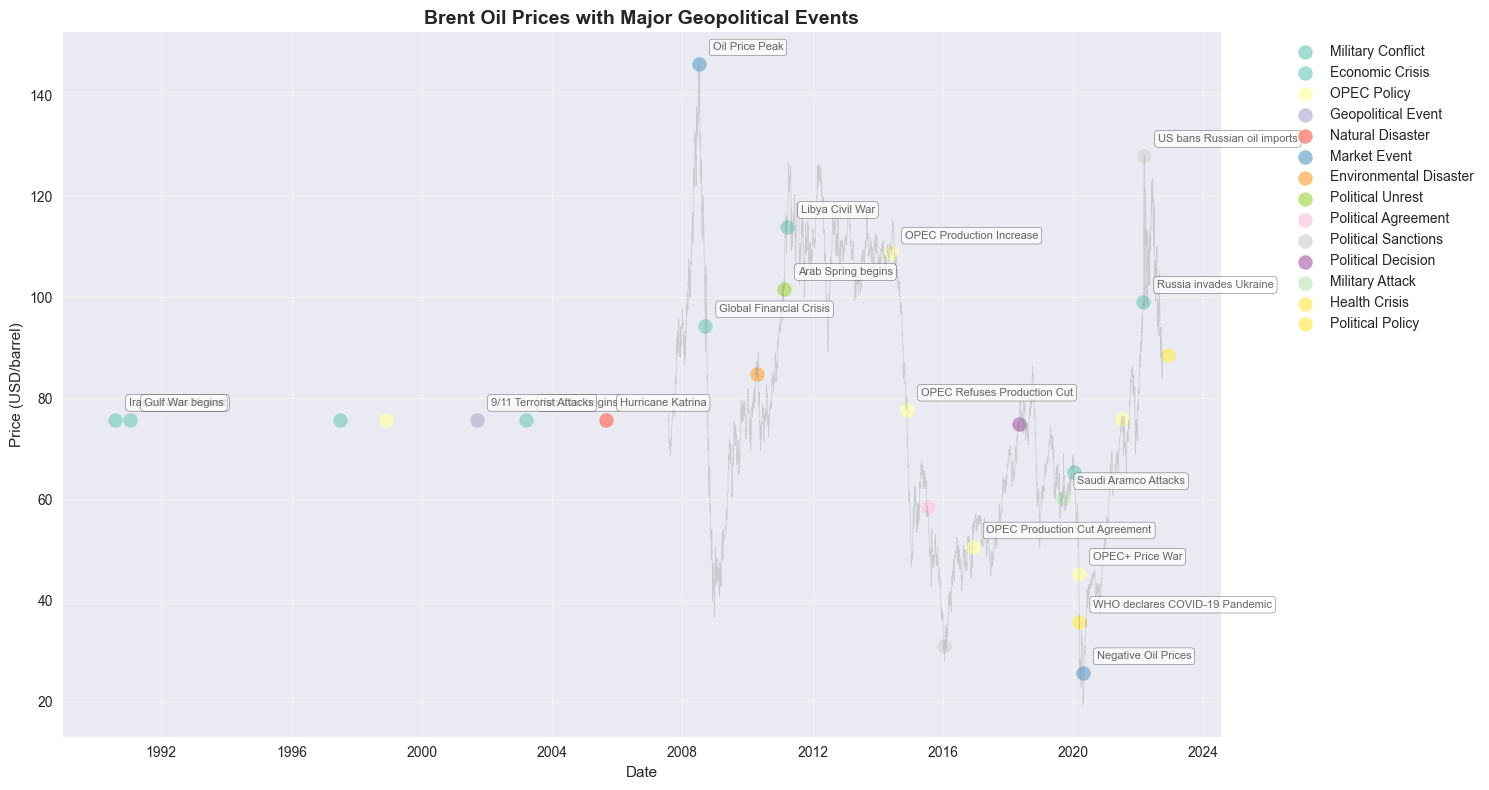

Event Analysis by Type:


,Count,High_Impact_Count
Type,,
Economic Crisis,2,1
Environmental Disaster,1,0
Geopolitical Event,1,1
Health Crisis,1,1
Market Event,2,2
Military Attack,1,1
Military Conflict,6,5
Natural Disaster,1,1
OPEC Policy,6,4


In [6]:
if 'events_data' in locals() and brent_data is not None:
    # Create timeline visualization
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Plot oil prices as background
    ax.plot(brent_data['Date'], brent_data['Price'], alpha=0.3, color='gray', linewidth=0.5)
    
    # Plot events with different colors for different types
    event_types = events_data['Type'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(event_types)))
    
    for i, event_type in enumerate(event_types):
        type_events = events_data[events_data['Type'] == event_type]
        
        for _, event in type_events.iterrows():
            # Find the closest oil price to the event date
            closest_price_idx = (brent_data['Date'] - event['Date']).abs().idxmin()
            event_price = brent_data.loc[closest_price_idx, 'Price']
            
            # Plot event marker
            ax.scatter(event['Date'], event_price, 
                      s=100, c=[colors[i]], alpha=0.8, 
                      label=event_type if _ == type_events.index[0] else "")
            
            # Add event label for high-impact events
            if event['Expected_Impact'] == 'High':
                ax.annotate(event['Event'], 
                           (event['Date'], event_price),
                           xytext=(10, 10), textcoords='offset points',
                           fontsize=8, alpha=0.7,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    ax.set_title('Brent Oil Prices with Major Geopolitical Events', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD/barrel)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Event type analysis
    print("Event Analysis by Type:")
    event_summary = events_data.groupby('Type').agg({
        'Event': 'count',
        'Expected_Impact': lambda x: (x == 'High').sum()
    }).rename(columns={'Event': 'Count', 'Expected_Impact': 'High_Impact_Count'})
    display(event_summary)

## 6. Data Preparation for Next Steps

In [7]:
# Prepare cleaned datasets for next analysis
if brent_data is not None:
    # Remove temporary columns
    brent_clean = brent_data.drop(['Decade', 'Rolling_Mean', 'Rolling_Std'], axis=1, errors='ignore')
    
    # Save cleaned data
    brent_clean.to_csv('../data/brent_oil_prices_clean.csv', index=False)
    print("✓ Cleaned Brent oil data saved to ../data/brent_oil_prices_clean.csv")
    
    # Basic statistics for report
    stats_summary = {
        'Total_Observations': len(brent_clean),
        'Date_Range_Start': brent_clean['Date'].min().strftime('%Y-%m-%d'),
        'Date_Range_End': brent_clean['Date'].max().strftime('%Y-%m-%d'),
        'Min_Price': brent_clean['Price'].min(),
        'Max_Price': brent_clean['Price'].max(),
        'Mean_Price': brent_clean['Price'].mean(),
        'Std_Price': brent_clean['Price'].std()
    }
    
    print("\nDataset Summary:")
    for key, value in stats_summary.items():
        print(f"{key}: {value}")

if 'events_data' in locals():
    # Save events data (already clean)
    events_data.to_csv('../data/geopolitical_events_clean.csv', index=False)
    print("✓ Cleaned events data saved to ../data/geopolitical_events_clean.csv")

✓ Cleaned Brent oil data saved to ../data/brent_oil_prices_clean.csv

Dataset Summary:
Total_Observations: 3766
Date_Range_Start: 2007-07-30
Date_Range_End: 2022-09-29
Min_Price: 19.329999923706055
Max_Price: 146.0800018310547
Mean_Price: 78.13853424049981
Std_Price: 25.952673451429003
✓ Cleaned events data saved to ../data/geopolitical_events_clean.csv


## 7. Next Steps

The data exploration reveals:
1. **Data Quality**: Clean datasets ready for analysis
2. **Price Patterns**: Clear volatility and trend changes over time
3. **Event Coverage**: Comprehensive collection of major geopolitical events
4. **Visual Correlations**: Apparent relationships between events and price movements

**Next notebooks will cover:**
- Time series statistical analysis (stationarity, volatility)
- Bayesian change point modeling with PyMC
- Event-change point association analysis
- Interactive dashboard development